BB84 without Eve
Number of transmitted qubits: 10000
Number of sifted bits: 4939
Alice sifted key:
0000000111011001011000010101100000110111001010110001001101101000110010101001100000110010010011001110
Bob sifted key:
0000000111011001011000010101100000110111001010110001001101101000110010101001100000110010010011001110
QBER: 0.0

BB84 with Eve intercept-resend
Number of transmitted qubits: 10000
Number of sifted bits: 5001
Alice sifted key:
0001000011010100110011010011000001101100111100010110000101100110001111000110010111011010110010101010
Bob sifted key:
0011000011010010110001110011001001001101101010000110100101100110001111000110101110010000000000101010
QBER: 0.2481503699260148

Estimated QBER without Eve: 0.0
Remaining key length without Eve: 3952
Estimated QBER with Eve: 0.238
Remaining key length with Eve: 4001


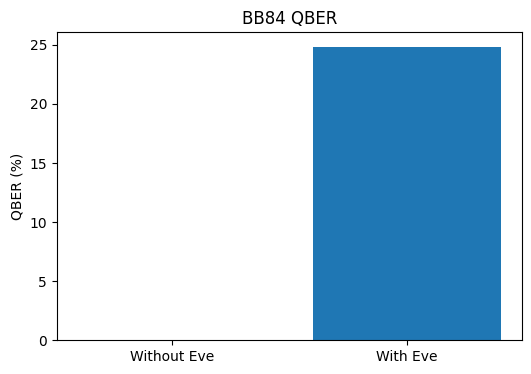

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()


def bb84_circuit(bit, preparation_basis, measurement_basis):
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)

    if preparation_basis == 1:
        qc.h(0)

    if measurement_basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    return qc


def measure_qubits(bits, preparation_bases, measurement_bases, seed=None):
    circuits = []

    for bit, prep_basis, measure_basis in zip(
        bits,
        preparation_bases,
        measurement_bases
    ):
        qc = bb84_circuit(
            int(bit),
            int(prep_basis),
            int(measure_basis)
        )

        circuits.append(qc)

    compiled_circuits = transpile(
        circuits,
        simulator
    )

    result = simulator.run(
        compiled_circuits,
        shots=1,
        memory=True,
        seed_simulator=seed
    ).result()

    measured_bits = []

    for i in range(len(compiled_circuits)):
        bit = int(result.get_memory(i)[0])
        measured_bits.append(bit)

    return np.array(measured_bits)


def sift_keys(
    alice_bits,
    alice_bases,
    bob_bits,
    bob_bases
):
    matching_positions = alice_bases == bob_bases

    alice_sifted_key = alice_bits[matching_positions]
    bob_sifted_key = bob_bits[matching_positions]

    return (
        matching_positions,
        alice_sifted_key,
        bob_sifted_key
    )


def calculate_qber(alice_key, bob_key):
    if len(alice_key) == 0:
        return 0

    errors = np.sum(alice_key != bob_key)

    qber = errors / len(alice_key)

    return qber


def bb84_without_eve(num_bits=1000, seed=1):
    rng = np.random.default_rng(seed)

    alice_bits = rng.integers(
        0,
        2,
        num_bits
    )

    alice_bases = rng.integers(
        0,
        2,
        num_bits
    )

    bob_bases = rng.integers(
        0,
        2,
        num_bits
    )

    bob_bits = measure_qubits(
        alice_bits,
        alice_bases,
        bob_bases,
        seed=seed
    )

    (
        matching_positions,
        alice_key,
        bob_key
    ) = sift_keys(
        alice_bits,
        alice_bases,
        bob_bits,
        bob_bases
    )

    qber = calculate_qber(
        alice_key,
        bob_key
    )

    return {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "bob_bases": bob_bases,
        "bob_bits": bob_bits,
        "matching_positions": matching_positions,
        "alice_key": alice_key,
        "bob_key": bob_key,
        "qber": qber
    }


def bb84_with_eve(num_bits=1000, seed=1):
    rng = np.random.default_rng(seed)

    alice_bits = rng.integers(
        0,
        2,
        num_bits
    )

    alice_bases = rng.integers(
        0,
        2,
        num_bits
    )

    eve_bases = rng.integers(
        0,
        2,
        num_bits
    )

    bob_bases = rng.integers(
        0,
        2,
        num_bits
    )

    eve_bits = measure_qubits(
        alice_bits,
        alice_bases,
        eve_bases,
        seed=seed + 1
    )

    bob_bits = measure_qubits(
        eve_bits,
        eve_bases,
        bob_bases,
        seed=seed + 2
    )

    (
        matching_positions,
        alice_key,
        bob_key
    ) = sift_keys(
        alice_bits,
        alice_bases,
        bob_bits,
        bob_bases
    )

    qber = calculate_qber(
        alice_key,
        bob_key
    )

    return {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "eve_bases": eve_bases,
        "eve_bits": eve_bits,
        "bob_bases": bob_bases,
        "bob_bits": bob_bits,
        "matching_positions": matching_positions,
        "alice_key": alice_key,
        "bob_key": bob_key,
        "qber": qber
    }


def estimate_qber(
    alice_key,
    bob_key,
    sample_fraction=0.2,
    seed=10
):
    rng = np.random.default_rng(seed)

    key_length = len(alice_key)

    sample_size = int(
        sample_fraction * key_length
    )

    if sample_size == 0:
        return 0, alice_key, bob_key

    sample_indices = rng.choice(
        key_length,
        size=sample_size,
        replace=False
    )

    sample_alice = alice_key[
        sample_indices
    ]

    sample_bob = bob_key[
        sample_indices
    ]

    estimated_qber = calculate_qber(
        sample_alice,
        sample_bob
    )

    keep_mask = np.ones(
        key_length,
        dtype=bool
    )

    keep_mask[
        sample_indices
    ] = False

    remaining_alice_key = alice_key[
        keep_mask
    ]

    remaining_bob_key = bob_key[
        keep_mask
    ]

    return (
        estimated_qber,
        remaining_alice_key,
        remaining_bob_key
    )


num_bits = 10000


ideal_result = bb84_without_eve(
    num_bits=num_bits,
    seed=20
)


eve_result = bb84_with_eve(
    num_bits=num_bits,
    seed=20
)


print("BB84 without Eve")

print(
    "Number of transmitted qubits:",
    num_bits
)

print(
    "Number of sifted bits:",
    len(ideal_result["alice_key"])
)

print(
    "Alice sifted key:"
)

print(
    "".join(
        map(
            str,
            ideal_result["alice_key"][:100]
        )
    )
)

print(
    "Bob sifted key:"
)

print(
    "".join(
        map(
            str,
            ideal_result["bob_key"][:100]
        )
    )
)

print(
    "QBER:",
    ideal_result["qber"]
)


print()


print("BB84 with Eve intercept-resend")

print(
    "Number of transmitted qubits:",
    num_bits
)

print(
    "Number of sifted bits:",
    len(eve_result["alice_key"])
)

print(
    "Alice sifted key:"
)

print(
    "".join(
        map(
            str,
            eve_result["alice_key"][:100]
        )
    )
)

print(
    "Bob sifted key:"
)

print(
    "".join(
        map(
            str,
            eve_result["bob_key"][:100]
        )
    )
)

print(
    "QBER:",
    eve_result["qber"]
)


estimated_ideal_qber, alice_final, bob_final = estimate_qber(
    ideal_result["alice_key"],
    ideal_result["bob_key"],
    sample_fraction=0.2,
    seed=50
)


estimated_eve_qber, alice_final_eve, bob_final_eve = estimate_qber(
    eve_result["alice_key"],
    eve_result["bob_key"],
    sample_fraction=0.2,
    seed=50
)


print()

print(
    "Estimated QBER without Eve:",
    estimated_ideal_qber
)

print(
    "Remaining key length without Eve:",
    len(alice_final)
)

print(
    "Estimated QBER with Eve:",
    estimated_eve_qber
)

print(
    "Remaining key length with Eve:",
    len(alice_final_eve)
)


plt.figure(
    figsize=(6, 4)
)

plt.bar(
    [
        "Without Eve",
        "With Eve"
    ],
    [
        100 * ideal_result["qber"],
        100 * eve_result["qber"]
    ]
)

plt.ylabel(
    "QBER (%)"
)

plt.title(
    "BB84 QBER"
)

plt.show()